# 1. Downloading the SVHN dataset

In [1]:
import torch
import torchvision
from torchvision import transforms

# Directory - saved data
data_dir = "./data"

# converting images to tensors
transform = transforms.ToTensor()

# training dataset - download
train_set = torchvision.datasets.SVHN(
    root=data_dir,
    split='train',
    download=True,
    transform=transform
)

# test dataset - download
test_set = torchvision.datasets.SVHN(
    root=data_dir,
    split='test',
    download=True,
    transform=transform
)

print("SVHN dataset downloaded!")
print(f"Training samples: {len(train_set)}")
print(f"Testing samples:  {len(test_set)}")


100%|██████████| 182M/182M [00:03<00:00, 49.8MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 43.7MB/s]


SVHN dataset downloaded!
Training samples: 73257
Testing samples:  26032


# 2. Transforms and DataLoaders

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Data augmentation: random cropping
    transforms.RandomHorizontalFlip(),      # Data augmentation: flip left/right
    transforms.ToTensor(),                  # Converting image to PyTorch tensor
    transforms.Normalize(                   # Normalize each channel
        mean=[0.4377, 0.4438, 0.4728],      # channel means
        std=[0.1980, 0.2010, 0.1970]        # channel stds
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4377, 0.4438, 0.4728],
        std=[0.1980, 0.2010, 0.1970]
    )
])

# Reloading datasets with transforms
train_set = torchvision.datasets.SVHN(
    root=data_dir,
    split='train',
    download=False,
    transform=train_transform
)

test_set = torchvision.datasets.SVHN(
    root=data_dir,
    split='test',
    download=False,
    transform=test_transform
)

# 3. DataLoaders
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print("DataLoaders ready!")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")


DataLoaders ready!
Train batches: 573
Test batches:  204


# 3. WideResNet-28-10 Implementation

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Basic Residual Block
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(BasicBlock, self).__init__()

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

        # Shortcut connection (for matching dimensions)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1, stride=stride, bias=False
            )

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        out += self.shortcut(x)
        return out

# Network Block
class NetworkBlock(nn.Module):
    def __init__(self, num_layers, in_channels, out_channels, stride):
        super(NetworkBlock, self).__init__()

        layers = []
        for i in range(num_layers):
            # First block may use stride to downsample
            layers.append(
                BasicBlock(
                    in_channels if i == 0 else out_channels,
                    out_channels,
                    stride if i == 0 else 1
                )
            )
        self.layer = nn.Sequential(*layers)

    def forward(self, x):
        return self.layer(x)

#  WideResNet Model
class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, num_classes=10):
        super(WideResNet, self).__init__()

        assert (depth - 4) % 6 == 0, "Depth should be 6n+4"
        n = (depth - 4) // 6

        k = widen_factor
        channels = [16, 16*k, 32*k, 64*k]  # Increasing channels

        # Initial convolution
        self.conv1 = nn.Conv2d(
            3, channels[0], kernel_size=3, stride=1, padding=1, bias=False
        )

        # 3 blocks
        self.block1 = NetworkBlock(n, channels[0], channels[1], stride=1)
        self.block2 = NetworkBlock(n, channels[1], channels[2], stride=2)
        self.block3 = NetworkBlock(n, channels[2], channels[3], stride=2)

        # BatchNorm + ReLU
        self.bn = nn.BatchNorm2d(channels[3])

        # Classifier
        self.fc = nn.Linear(channels[3], num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = F.relu(self.bn(out))
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.fc(out)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WideResNet(depth=28, widen_factor=10, num_classes=10).to(device)

print(model)
print("Model ready on device:", device)


WideResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (block1): NetworkBlock(
    (layer): Sequential(
      (0): BasicBlock(
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(16, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (shortcut): Conv2d(16, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BasicBlock(
        (bn1): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(160, 160, kerne

# 4. Training Setup

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Loss function
criterion = nn.CrossEntropyLoss()

# 2. Optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,            # Starting learning rate
    momentum=0.9,      # Helps accelerate training
    weight_decay=5e-4  # L2 regularization (reduces overfitting)
)

# 3. Learning Rate Scheduler
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[60, 120, 160],   # epochs where LR drops
    gamma=0.2                     # multiply LR by 0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training setup complete. Using device:", device)


# 4. Training loop
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        # accuracy
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# 5. Evaluation loop
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy

print("Training and evaluation functions are ready!")


Training setup complete. Using device: cuda
Training and evaluation functions are ready!


# 5. Training the Model

In [5]:
num_epochs = 10
best_accuracy = 0
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):

    print(f"\nEpoch {epoch}/{num_epochs} ...")

    # Training for one epoch
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # Evaluation - test set
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    # Updating learning rate
    scheduler.step()

    # Saving metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Progress
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")

    # Saving best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), "best_wideresnet_svhn.pth")
        print(">>> New best model saved!")

print("\nTraining complete!")
print(f"Best test accuracy: {best_accuracy:.2f}%")


Epoch 1/10 ...
Train Loss: 1.4349 | Train Acc: 50.12%
Test Loss:  1.3241 | Test Acc:  66.12%
>>> New best model saved!

Epoch 2/10 ...
Train Loss: 0.4402 | Train Acc: 86.24%
Test Loss:  0.3868 | Test Acc:  88.05%
>>> New best model saved!

Epoch 3/10 ...
Train Loss: 0.3594 | Train Acc: 89.13%
Test Loss:  0.4499 | Test Acc:  86.16%

Epoch 4/10 ...
Train Loss: 0.3260 | Train Acc: 90.13%
Test Loss:  0.3836 | Test Acc:  87.94%

Epoch 5/10 ...
Train Loss: 0.3123 | Train Acc: 90.57%
Test Loss:  0.3802 | Test Acc:  88.26%
>>> New best model saved!

Epoch 6/10 ...
Train Loss: 0.3042 | Train Acc: 90.82%
Test Loss:  0.2980 | Test Acc:  91.36%
>>> New best model saved!

Epoch 7/10 ...
Train Loss: 0.2998 | Train Acc: 91.20%
Test Loss:  0.2775 | Test Acc:  91.93%
>>> New best model saved!

Epoch 8/10 ...
Train Loss: 0.2989 | Train Acc: 91.03%
Test Loss:  0.2995 | Test Acc:  91.09%

Epoch 9/10 ...
Train Loss: 0.2900 | Train Acc: 91.39%
Test Loss:  0.3956 | Test Acc:  88.00%

Epoch 10/10 ...
Train L

In [6]:
import pickle

with open("metrics.pkl", "wb") as f:
    pickle.dump({
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies
    }, f)

print("Training metrics saved to metrics.pkl!")


Training metrics saved to metrics.pkl!


In [7]:
import os
print(os.path.getsize("/content/best_wideresnet_svhn.pth") / 1_000_000, "MB")


146.043446 MB


# 5.1. Loading Saved Model

In [8]:
model_path = "/content/best_wideresnet_svhn.pth"
metrics_path = "/content/metrics.pkl"

# Recreating the model architecture
loaded_model = WideResNet(depth=28, widen_factor=10, num_classes=10).to(device)

# Loading the saved weights
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

print("Model loaded successfully!")

# 3. Loading training metrics (for loss/accuracy curves)
import pickle

with open(metrics_path, "rb") as f:
    metrics = pickle.load(f)

train_losses = metrics["train_losses"]
test_losses = metrics["test_losses"]
train_accuracies = metrics["train_accuracies"]
test_accuracies = metrics["test_accuracies"]

print("Training metrics loaded successfully!")

Model loaded successfully!
Training metrics loaded successfully!


# 6. Evaluation and Plots


Final Test Loss: 0.2775
Final Test Accuracy: 91.93%


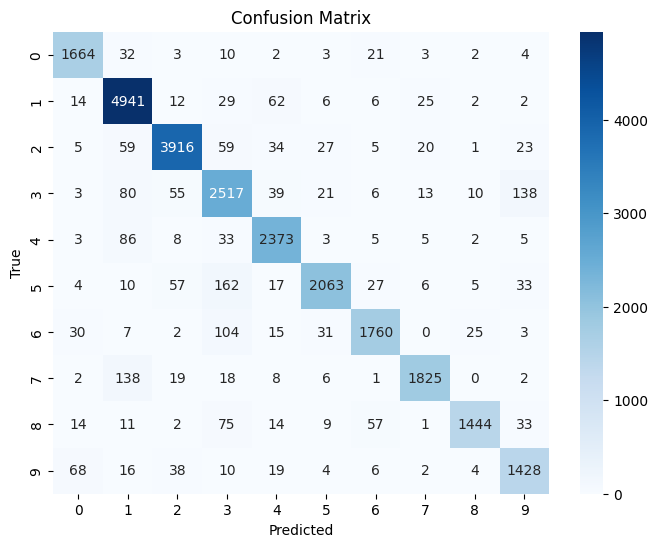

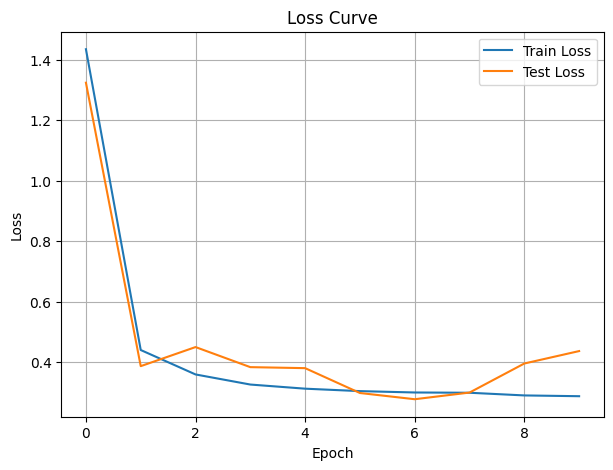

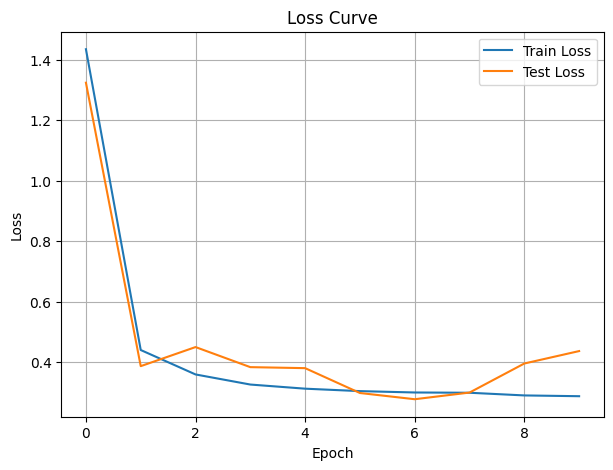

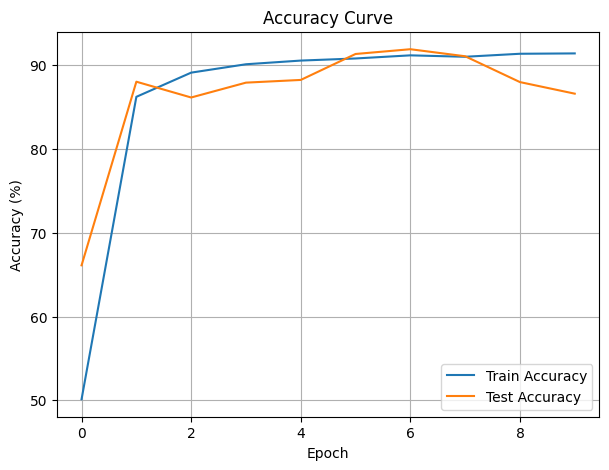

In [9]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


best_model = loaded_model

# Final accuracy and loss
final_test_loss, final_test_acc = evaluate(
    best_model, test_loader, criterion, device
)

print(f"\nFinal Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")


# Confusion Matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# Loss Curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

if "train_losses" in globals():
    plt.figure(figsize=(7, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# Accuracy Curves
plt.figure(figsize=(7, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()



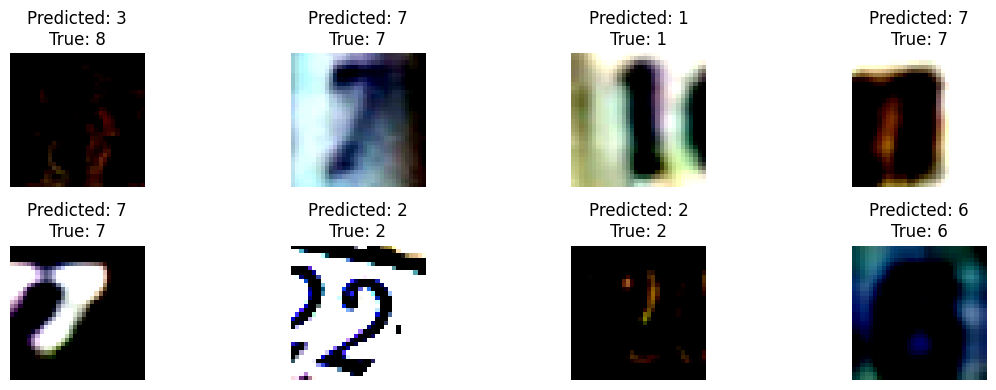

In [10]:
# Random test-set predictions

import matplotlib.pyplot as plt
import torch

# evaluation mode
best_model.eval()

# random samples
samples = torch.randint(0, len(test_set), (8,))

plt.figure(figsize=(12, 4))

for i, idx in enumerate(samples):
    image, label = test_set[idx]
    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_model(input_img)
        prediction = output.argmax(1).item()

    plt.subplot(2, 4, i+1)
    plt.imshow(image.permute(1, 2, 0).cpu())
    plt.title(f"Predicted: {prediction}\nTrue: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


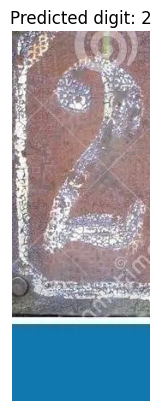

Prediction: 2


In [12]:
# Prediction - custom image

from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

image_path = "/content/Image1.jpeg"
img = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4377, 0.4438, 0.4728],
        std=[0.1980, 0.2010, 0.1970]
    )
])

input_tensor = transform(img).unsqueeze(0).to(device)

# Prediction
best_model.eval()
with torch.no_grad():
    output = best_model(input_tensor)
    prediction = output.argmax(1).item()

plt.imshow(img)
plt.title(f"Predicted digit: {prediction}")
plt.axis("off")
plt.show()

print("Prediction:", prediction)


Total misclassified test images: 2101


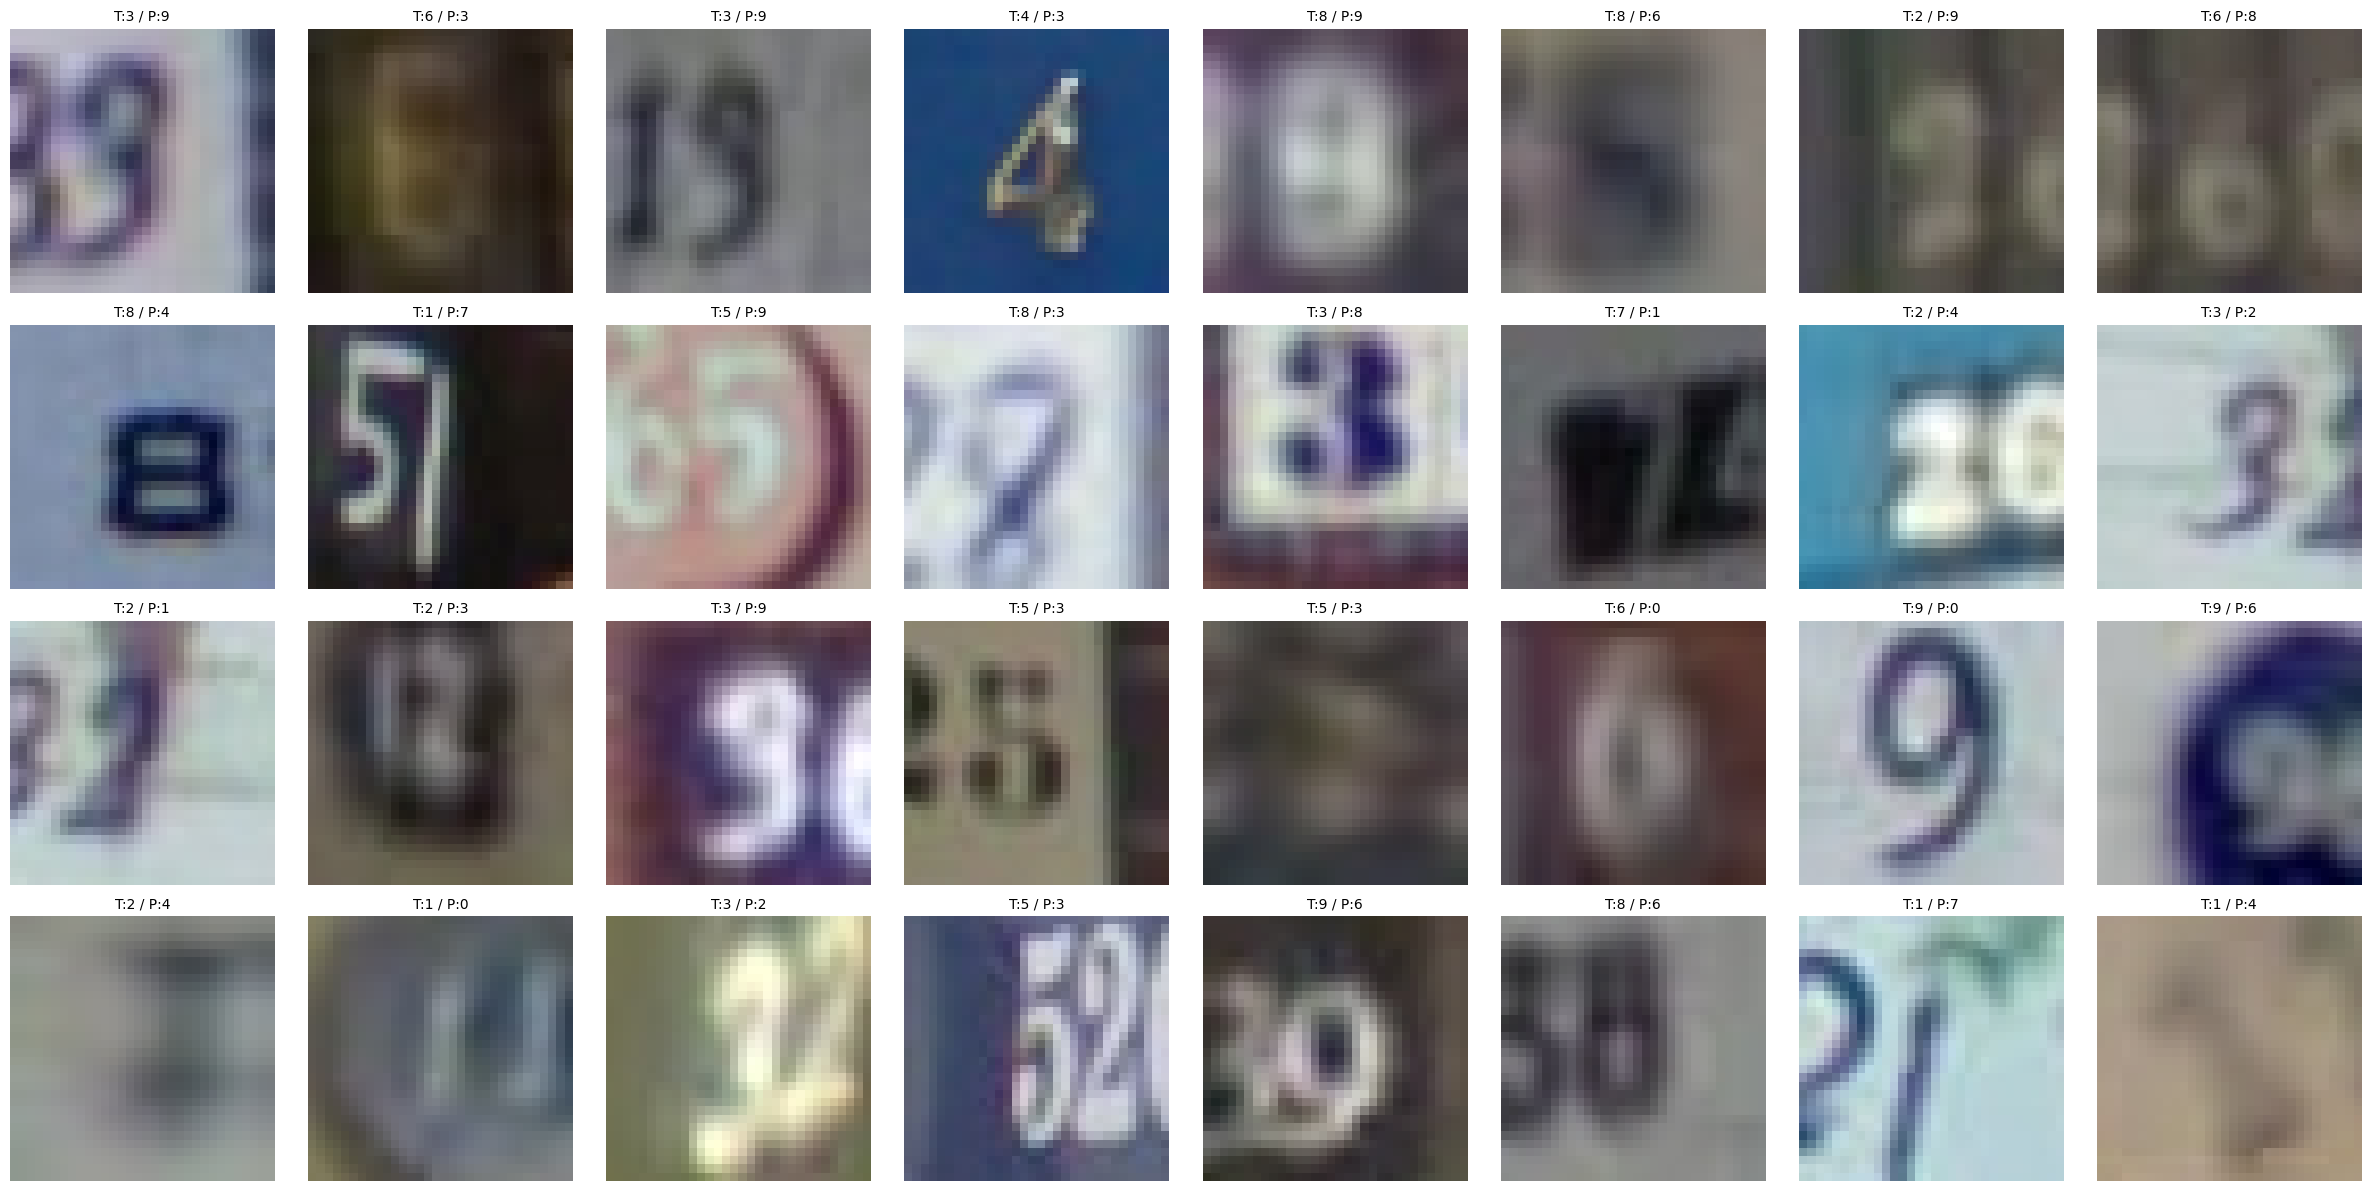


Per-class accuracy:
Digit 0: 95.41%  (samples: 1744)
Digit 1: 96.90%  (samples: 5099)
Digit 2: 94.38%  (samples: 4149)
Digit 3: 87.34%  (samples: 2882)
Digit 4: 94.05%  (samples: 2523)
Digit 5: 86.54%  (samples: 2384)
Digit 6: 89.02%  (samples: 1977)
Digit 7: 90.39%  (samples: 2019)
Digit 8: 86.99%  (samples: 1660)
Digit 9: 89.53%  (samples: 1595)


In [13]:
# Missclassifications and per-class accuracy

import torch
import matplotlib.pyplot as plt
import numpy as np

best_model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

# Collecting misclassified examples
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, preds = outputs.max(1)

        mask = preds != labels
        if mask.any():
            wrong_images.append(images[mask].cpu())
            wrong_preds.append(preds[mask].cpu())
            wrong_labels.append(labels[mask].cpu())

if len(wrong_images) > 0:
    wrong_images = torch.cat(wrong_images)
    wrong_preds = torch.cat(wrong_preds)
    wrong_labels = torch.cat(wrong_labels)
    print(f"Total misclassified test images: {len(wrong_images)}")
else:
    print("No misclassified images!")

# Un-normalization function
mean = torch.tensor([0.4377, 0.4438, 0.4728])
std = torch.tensor([0.1980, 0.2010, 0.1970])

def unnormalize(img):
    return (img * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

def show_wrong_examples(n=32):
    if len(wrong_images) == 0:
        print("No wrong examples.")
        return

    n = min(n, len(wrong_images))
    rows = 4
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        img = unnormalize(wrong_images[i]).permute(1, 2, 0)  # CHW -> HWC

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        true_label = wrong_labels[i].item()
        pred_label = wrong_preds[i].item()
        ax.set_title(f"T:{true_label} / P:{pred_label}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_wrong_examples(32)

# Per-class accuracy
num_classes = 10
class_correct = torch.zeros(num_classes)
class_total = torch.zeros(num_classes)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, preds = outputs.max(1)

        for c in range(num_classes):
            mask = labels == c
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c] += mask.sum().item()

print("\nPer-class accuracy:")
for c in range(num_classes):
    if class_total[c] > 0:
        acc = 100.0 * class_correct[c] / class_total[c]
        print(f"Digit {c}: {acc:.2f}%  (samples: {int(class_total[c].item())})")


# 7. ResNet-18 (for comparison)

In [14]:
# 7.1 — Defining ResNet-18 for SVHN

import torchvision.models as models
import torch.nn as nn

print("Creating ResNet-18...")

resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(resnet18.fc.in_features, 10)
resnet18 = resnet18.to(device)

print("ResNet-18 created successfully!")


Creating ResNet-18...
ResNet-18 created successfully!


In [15]:
# 7.2 — Training ResNet-18

epochs_resnet = 10
optimizer_resnet = torch.optim.Adam(resnet18.parameters(), lr=0.001)
best_acc_resnet = 0

train_losses_resnet = []
test_losses_resnet = []
train_acc_resnet = []
test_acc_resnet = []

for epoch in range(epochs_resnet):
    print(f"\n Epoch {epoch+1}/{epochs_resnet} ...")

    # Training
    resnet18.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    # Testing
    resnet18.eval()
    test_loss, test_acc = evaluate(resnet18, test_loader, criterion, device)

    train_losses_resnet.append(epoch_train_loss)
    test_losses_resnet.append(test_loss)
    train_acc_resnet.append(epoch_train_acc)
    test_acc_resnet.append(test_acc)

    print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if test_acc > best_acc_resnet:
        best_acc_resnet = test_acc
        torch.save(resnet18.state_dict(), "best_resnet18_svhn.pth")
        print("New BEST model saved!")

print("\nTraining ResNet-18 complete!")
print(f"Best Test Accuracy: {best_acc_resnet:.2f}%")



 Epoch 1/10 ...
Train Loss: 1.3217, Train Acc: 54.01%
Test Loss: 0.6728, Test Acc: 77.87%
New BEST model saved!

 Epoch 2/10 ...
Train Loss: 0.6262, Train Acc: 79.81%
Test Loss: 0.5090, Test Acc: 83.86%
New BEST model saved!

 Epoch 3/10 ...
Train Loss: 0.5028, Train Acc: 83.98%
Test Loss: 0.3803, Test Acc: 88.11%
New BEST model saved!

 Epoch 4/10 ...
Train Loss: 0.4456, Train Acc: 85.92%
Test Loss: 0.3629, Test Acc: 88.97%
New BEST model saved!

 Epoch 5/10 ...
Train Loss: 0.4106, Train Acc: 87.42%
Test Loss: 0.3733, Test Acc: 88.57%

 Epoch 6/10 ...
Train Loss: 0.3855, Train Acc: 87.97%
Test Loss: 0.3329, Test Acc: 89.84%
New BEST model saved!

 Epoch 7/10 ...
Train Loss: 0.3675, Train Acc: 88.64%
Test Loss: 0.3353, Test Acc: 89.83%

 Epoch 8/10 ...
Train Loss: 0.3507, Train Acc: 89.17%
Test Loss: 0.2929, Test Acc: 91.23%
New BEST model saved!

 Epoch 9/10 ...
Train Loss: 0.3287, Train Acc: 89.81%
Test Loss: 0.2858, Test Acc: 91.35%
New BEST model saved!

 Epoch 10/10 ...
Train Los

ResNet-18 loaded successfully!

Final ResNet-18 Test Loss: 0.2694
Final ResNet-18 Test Accuracy: 92.06%


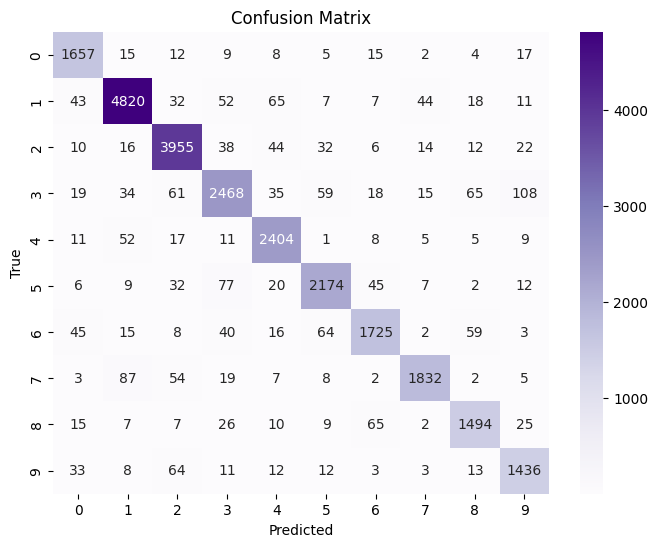

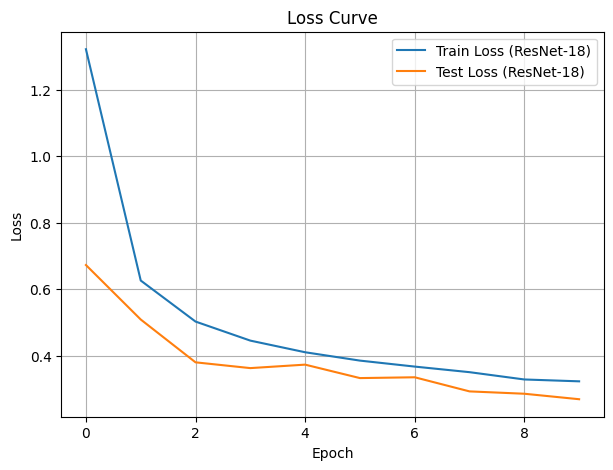

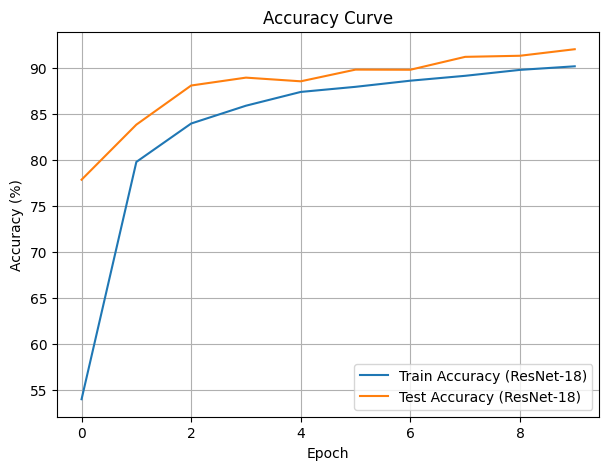

In [16]:
# 7.3 — Evaluating ResNet-18

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pickle
import torch.nn as nn
import torchvision.models as models

# Recreating ResNet-18 architecture
best_resnet = models.resnet18(weights=None)
best_resnet.fc = nn.Linear(best_resnet.fc.in_features, 10)
best_resnet = best_resnet.to(device)

best_resnet.load_state_dict(torch.load("best_resnet18_svhn.pth", map_location=device))
best_resnet.eval()

print("ResNet-18 loaded successfully!")


# Final Test Accuracy + loss
loss_rn, acc_rn = evaluate(best_resnet, test_loader, criterion, device)

print(f"\nFinal ResNet-18 Test Loss: {loss_rn:.4f}")
print(f"Final ResNet-18 Test Accuracy: {acc_rn:.2f}%")


# Confusion Matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_resnet(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Purples", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# Loss Curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses_resnet, label="Train Loss (ResNet-18)")
plt.plot(test_losses_resnet, label="Test Loss (ResNet-18)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy Curves
plt.figure(figsize=(7, 5))
plt.plot(train_acc_resnet, label="Train Accuracy (ResNet-18)")
plt.plot(test_acc_resnet, label="Test Accuracy (ResNet-18)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

#resnet_metrics = {
#    "train_losses_resnet": train_losses_resnet,
#    "test_losses_resnet": test_losses_resnet,
#    "train_acc_resnet": train_acc_resnet,
#    "test_acc_resnet": test_acc_resnet
#}

#with open("metrics_resnet18.pkl", "wb") as f:
#    pickle.dump(resnet_metrics, f)

#print("ResNet-18 training metrics saved to metrics_resnet18.pkl!")


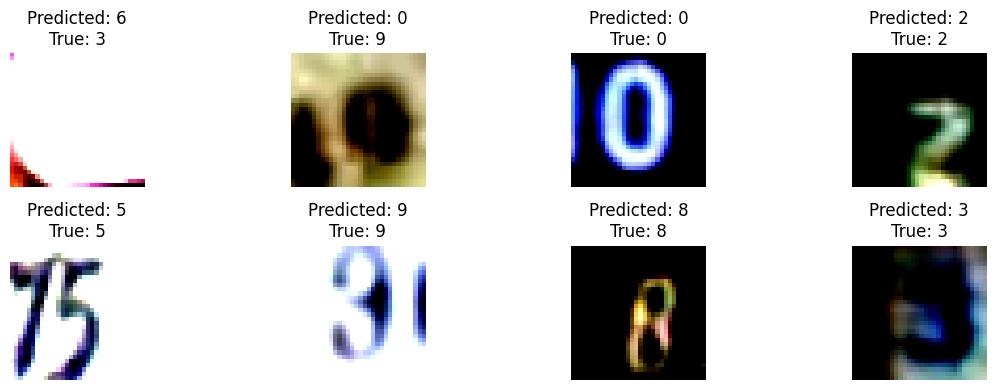

In [17]:
#7.3.1 Random test-set predictions

import matplotlib.pyplot as plt
import torch

best_resnet.eval()

samples = torch.randint(0, len(test_set), (8,))

plt.figure(figsize=(12, 4))

for i, idx in enumerate(samples):
    image, label = test_set[idx]
    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_resnet(input_img)
        prediction = output.argmax(1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.permute(1, 2, 0).cpu())
    plt.title(f"Predicted: {prediction}\nTrue: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


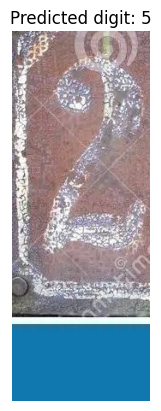

Prediction: 5


In [18]:
#7.3.2 — ResNet-18 on custom image

from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

image_path = "/content/Image1.jpeg"

img = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4377, 0.4438, 0.4728],
        std=[0.1980, 0.2010, 0.1970]
    )
])

input_tensor = transform(img).unsqueeze(0).to(device)

# Prediction
best_resnet.eval()
with torch.no_grad():
    output = best_resnet(input_tensor)
    prediction = output.argmax(1).item()

plt.imshow(img)
plt.title(f"Predicted digit: {prediction}")
plt.axis("off")
plt.show()

print("Prediction:", prediction)


Total misclassified test images: 2067


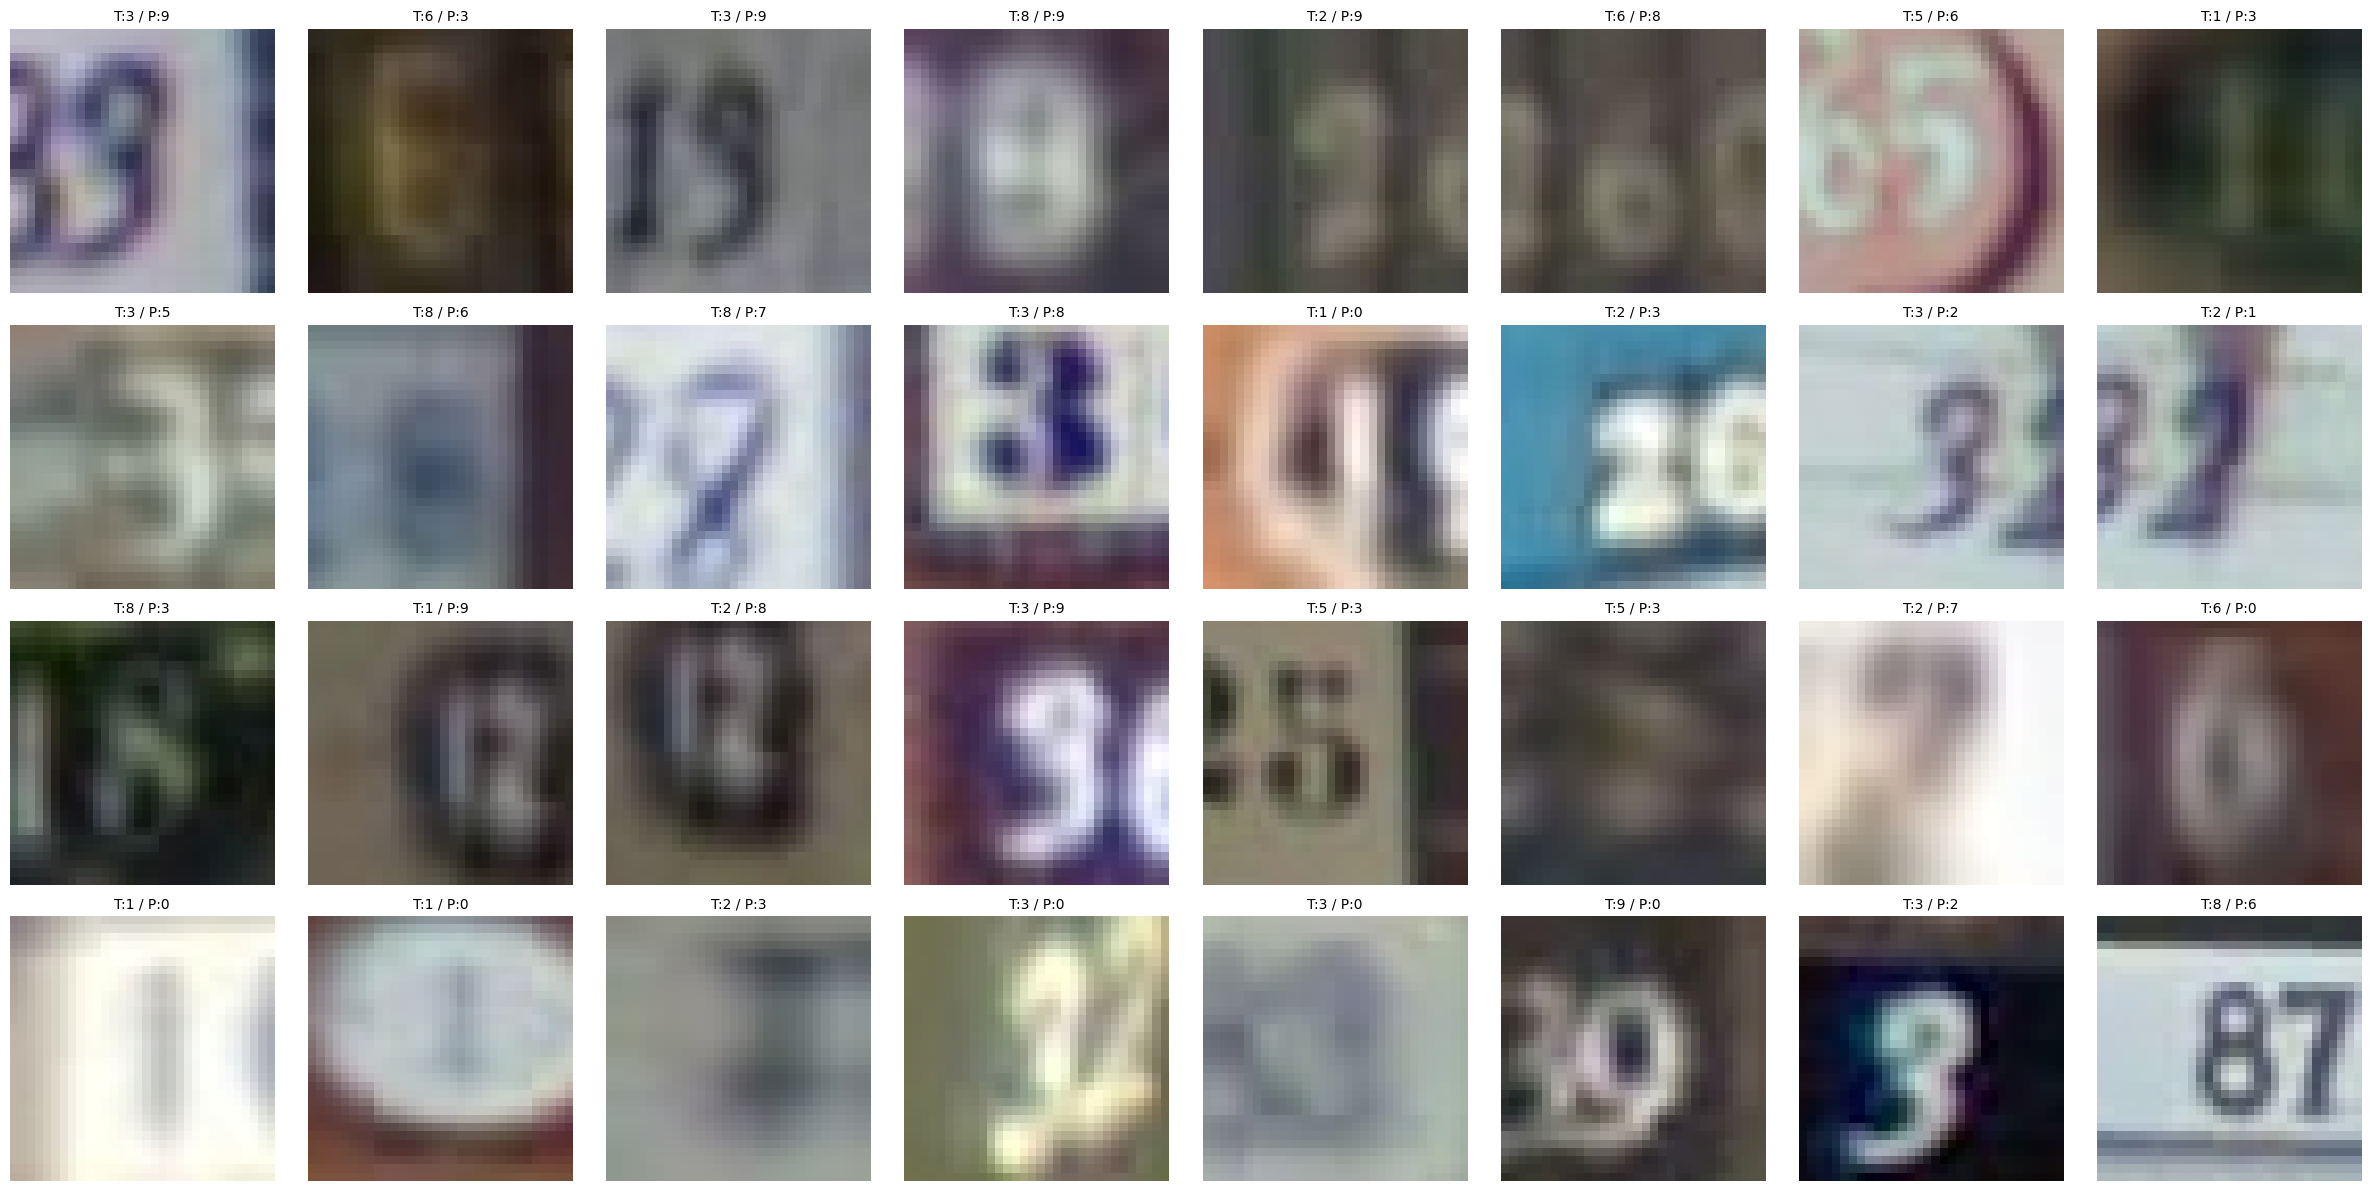


Per-class accuracy:
Digit 0: 95.01%  (samples: 1744)
Digit 1: 94.53%  (samples: 5099)
Digit 2: 95.32%  (samples: 4149)
Digit 3: 85.63%  (samples: 2882)
Digit 4: 95.28%  (samples: 2523)
Digit 5: 91.19%  (samples: 2384)
Digit 6: 87.25%  (samples: 1977)
Digit 7: 90.74%  (samples: 2019)
Digit 8: 90.00%  (samples: 1660)
Digit 9: 90.03%  (samples: 1595)


In [19]:
# 7.3.3 — Missclassifications and per-class accuracy for ResNet-18

import torch
import matplotlib.pyplot as plt
import numpy as np

best_resnet.eval()

wrong_images_rn = []
wrong_preds_rn = []
wrong_labels_rn = []

# Collecting misclassified examples
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_resnet(images)
        _, preds = outputs.max(1)

        mask = preds != labels
        if mask.any():
            wrong_images_rn.append(images[mask].cpu())
            wrong_preds_rn.append(preds[mask].cpu())
            wrong_labels_rn.append(labels[mask].cpu())

if len(wrong_images_rn) > 0:
    wrong_images_rn = torch.cat(wrong_images_rn)
    wrong_preds_rn = torch.cat(wrong_preds_rn)
    wrong_labels_rn = torch.cat(wrong_labels_rn)
    print(f"Total misclassified test images: {len(wrong_images_rn)}")
else:
    print("No misclassified images!")

# Un-normalization function
mean = torch.tensor([0.4377, 0.4438, 0.4728])
std = torch.tensor([0.1980, 0.2010, 0.1970])

def unnormalize(img):
    return (img * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

def show_wrong_examples_resnet(n=32):
    if len(wrong_images_rn) == 0:
        print("No wrong examples.")
        return

    n = min(n, len(wrong_images_rn))
    rows = 4
    cols = int(np.ceil(n / rows))

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        img = unnormalize(wrong_images_rn[i]).permute(1, 2, 0)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        true_label = wrong_labels_rn[i].item()
        pred_label = wrong_preds_rn[i].item()
        ax.set_title(f"T:{true_label} / P:{pred_label}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_wrong_examples_resnet(32)

# Per-class accuracy
num_classes = 10
class_correct = torch.zeros(num_classes)
class_total = torch.zeros(num_classes)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_resnet(images)
        _, preds = outputs.max(1)

        for c in range(num_classes):
            mask = labels == c
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c] += mask.sum().item()

print("\nPer-class accuracy:")
for c in range(num_classes):
    if class_total[c] > 0:
        acc = 100.0 * class_correct[c] / class_total[c]
        print(f"Digit {c}: {acc:.2f}%  (samples: {int(class_total[c].item())})")


In [ ]:

_, best_accuracy = evaluate(loaded_model, test_loader, criterion, device)


# 8. Comparison Summary

In [20]:
print(f"WideResNet-28-10 best accuracy: {best_accuracy:.2f}%")
print(f"ResNet-18 best accuracy:       {best_acc_resnet:.2f}%")

print("\nParameter count:")
from torchsummary import summary

dummy_input = torch.randn(1, 3, 32, 32).to(device)

print("\nWideResNet-28-10 parameters:")
summary(loaded_model, (3, 32, 32))

print("\nResNet-18 parameters:")
summary(best_resnet, (3, 32, 32))


WideResNet-28-10 best accuracy: 91.93%
ResNet-18 best accuracy:       92.06%

Parameter count:

WideResNet-28-10 parameters:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
            Conv2d-3          [-1, 160, 32, 32]          23,040
       BatchNorm2d-4          [-1, 160, 32, 32]             320
            Conv2d-5          [-1, 160, 32, 32]         230,400
            Conv2d-6          [-1, 160, 32, 32]           2,560
        BasicBlock-7          [-1, 160, 32, 32]               0
       BatchNorm2d-8          [-1, 160, 32, 32]             320
            Conv2d-9          [-1, 160, 32, 32]         230,400
      BatchNorm2d-10          [-1, 160, 32, 32]             320
           Conv2d-11          [-1, 160, 32, 32]         230,400
       BasicBlock-12          [-1, 160, 32